# Skin Detection in Digital Images

## Overview

Skin detection is an essential sub-task in various computer vision applications such as face recognition, hand gesture recognition, and human-computer interaction. The primary aim is to identify skin-colored pixels and regions in an image or video stream. Effective skin detection can significantly enhance the performance of these applications by reducing the search space and eliminating non-skin regions.

However, skin detection is challenging due to various factors such as:

- **Variability in skin tones:** People have different skin tones based on ethnic backgrounds.
- **Lighting conditions:** Different illumination conditions can alter the perceived skin color.
- **Camera Variability:** Different cameras and settings can affect the color consistency.
- **Noise:** Image artifacts, sensor noise, or other elements can disrupt skin detection.

## Techniques

In this notebook, we'll explore some standard techniques for skin detection, which are:

1. **Color-based Skin Detection:** This is the simplest form of skin detection and is based on a range of skin color values. However, this method is not very robust to changes in lighting conditions.

2. **Probabilistic Models:** These models are based on the statistical distribution of skin and non-skin colors in the image. They are generally more robust than simple color-based models.

3. **Normalized Color Spaces:** Using normalized color spaces like $ \text{r} = \frac{R}{R+G+B} $ and $ \text{g} = \frac{G}{R+G+B} $ to create a more lighting-invariant representation.

4. **Histogram-based Methods:** These involve creating histograms of skin and non-skin colors and then using these histograms to classify each pixel.

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## Color-based Skin Detection

In color-based skin detection, pixels that fall within a certain range of color intensity values are detected as skin pixels. 

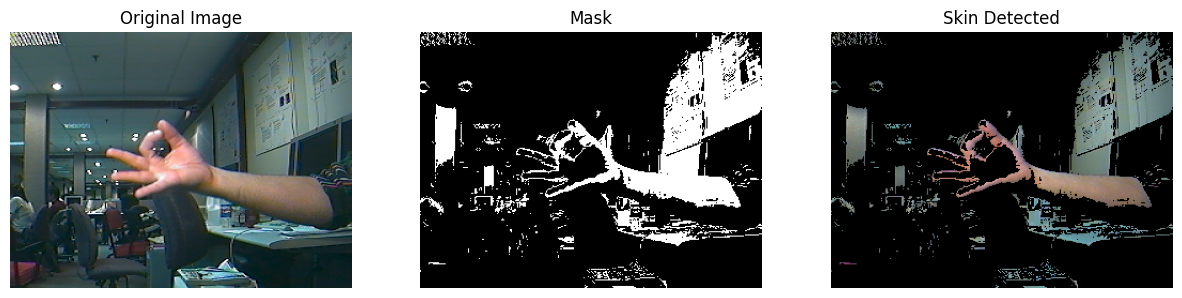

In [15]:
# Read the image
image = cv2.imread('data/frame20.bmp')

# Convert BGR image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define RGB range for skin color
lower_skin = np.array([90, 40, 85], dtype=np.uint8)
upper_skin = np.array([210, 180, 210], dtype=np.uint8)

# Create a mask using inRange function
mask = cv2.inRange(image_rgb, lower_skin, upper_skin)

# Bitwise-AND mask and image
res_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

# Display images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Skin Detected")
plt.imshow(res_rgb)
plt.axis("off")

plt.show()

## Probabilistic Models for Skin Detection

In probabilistic models for skin detection we build a model of the distribution of values for skin pixels. Then, we use this model to classify each pixel as skin or non-skin. We assume the skin pixels are distributed according to a Gaussian distribution.

In [16]:
def gaussian_probability(mean, std, values):
    """
    Calculate Gaussian probability based on given mean and standard deviation for each value.
    
    Parameters:
        mean (float): The mean of the distribution.
        std (float): The standard deviation of the distribution.
        values (numpy.ndarray): The array of values for which to calculate the Gaussian probabilities.
        
    Returns:
        numpy.ndarray: The array of Gaussian probabilities for the input values.
    """
    return np.exp(-((values - mean)**2) / (2 * std ** 2)) / (std * np.sqrt(2 * np.pi))

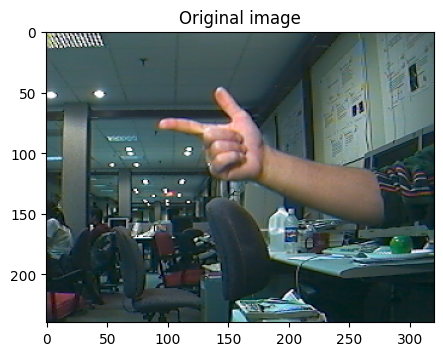

In [17]:
# Read the image
frame2 = cv2.imread('data/frame2.bmp')

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title('Original image')
plt.show()

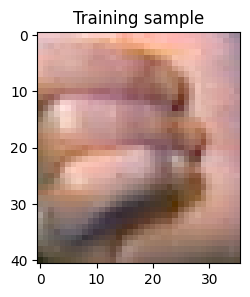

In [18]:
# Get the training sample
sample = frame2[79:120, 136:172].astype(np.float64)

# Display the training sample
plt.figure(figsize=(3, 3))
plt.imshow(cv2.cvtColor(sample.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title('Training sample')
plt.show()

In [19]:
def display_images(original, detection, binary):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(original.astype(np.uint8))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Skin Detection")
    plt.imshow(detection, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Detected Skin Pixels")
    plt.imshow(binary, cmap='gray')
    plt.axis("off")

    plt.show()

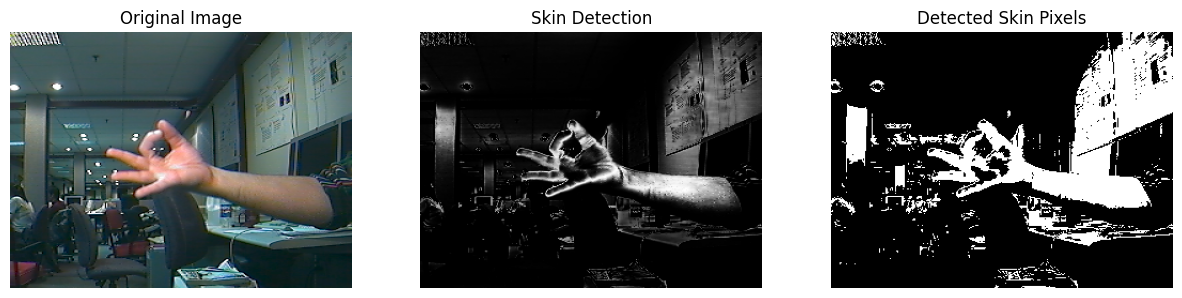

In [20]:
# Extract the colors
sample_red = sample[:,:,2].ravel() # ravel() flattens the array. Similar to reshape(-1) and flatten().
sample_green = sample[:,:,1].ravel()
sample_blue = sample[:,:,0].ravel()

# Compute mean and std
red_mean = np.mean(sample_red)
green_mean = np.mean(sample_green)
blue_mean = np.mean(sample_blue)
red_std = np.std(sample_red)
green_std = np.std(sample_green)
blue_std = np.std(sample_blue)

# Read another image to apply the model
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)
rows, cols, bands = frame20.shape

skin_detection = np.zeros((rows, cols))

for row in range(rows):
    for col in range(cols):
        red = frame20[row, col, 0]
        green = frame20[row, col, 1]
        blue = frame20[row, col, 2]
        
        red_pr = gaussian_probability(red_mean, red_std, red)
        green_pr = gaussian_probability(green_mean, green_std, green)
        blue_pr = gaussian_probability(blue_mean, blue_std, blue)
        
        prob = red_pr * green_pr * blue_pr
        skin_detection[row, col] = prob     # P(RGB|skin)

# Display images
display_images(frame20, skin_detection, skin_detection > .0000001)


## Normalized Color Spaces

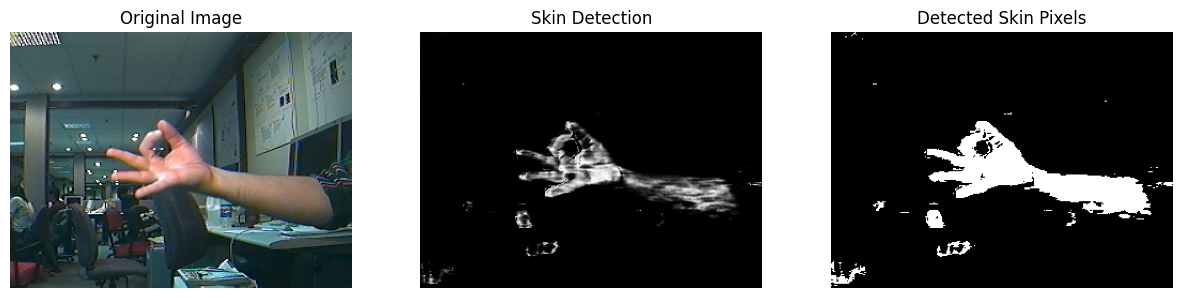

In [21]:
# Read the image
frame2 = cv2.imread('data/frame2.bmp').astype(np.float64)

# Get the training skin sample
sample = frame2[79:120, 136:172]

# Extract the colors
sample_red = sample[:,:,2].ravel()
sample_green = sample[:,:,1].ravel()
sample_blue = sample[:,:,0].ravel()

# Normalize red and green
sample_total = sample_red + sample_green + sample_blue
sample_red2 = np.divide(sample_red, sample_total, where=sample_total != 0)
sample_green2 = np.divide(sample_green, sample_total, where=sample_total != 0)

# Compute mean and std in normalized rg space
r_mean = np.mean(sample_red2)
g_mean = np.mean(sample_green2)
r_std = np.std(sample_red2)
g_std = np.std(sample_green2)

# Read another image to apply the model
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)
rows, cols, bands = frame20.shape

skin_detection2 = np.zeros((rows, cols))

for row in range(rows):
    for col in range(cols):
        red = frame20[row, col, 0]
        green = frame20[row, col, 1]
        blue = frame20[row, col, 2]
        
        total = red + green + blue
        if total > 0:
            r = red / total
            g = green / total
        else:
            r = 0
            g = 0
            
        r_prob = gaussian_probability(r_mean, r_std, r)
        g_prob = gaussian_probability(g_mean, g_std, g)
        
        prob = r_prob * g_prob
        skin_detection2[row, col] = prob

# Display images
display_images(frame20, skin_detection2, skin_detection2 > 10)

## Histogram-based Methods

#### Using only positive histogram

In [22]:
def detect_skin2(image, positive_histogram):
    """
    Detect skin in the given image based on a precomputed positive_histogram.
    
    Parameters:
        image (numpy.ndarray): The input image array with shape (vertical_size, horizontal_size, 3).
        positive_histogram (numpy.ndarray): The precomputed positive histogram for skin detection.
        
    Returns:
        numpy.ndarray: The result of skin detection, an array with shape (vertical_size, horizontal_size).
    """

    vertical_size, horizontal_size, _ = image.shape
    histogram_bins = positive_histogram.shape[0]
    factor = 256 / histogram_bins
    
    result = np.zeros((vertical_size, horizontal_size))
    
    for vertical in range(vertical_size):
        for horizontal in range(horizontal_size):
            red = image[vertical, horizontal, 0]
            green = image[vertical, horizontal, 1]
            blue = image[vertical, horizontal, 2]
            
            r_index = int(np.floor(red / factor))
            g_index = int(np.floor(green / factor))
            b_index = int(np.floor(blue / factor))
            
            skin_value = positive_histogram[r_index, g_index, b_index]
            result[vertical, horizontal] = skin_value
            
    return result

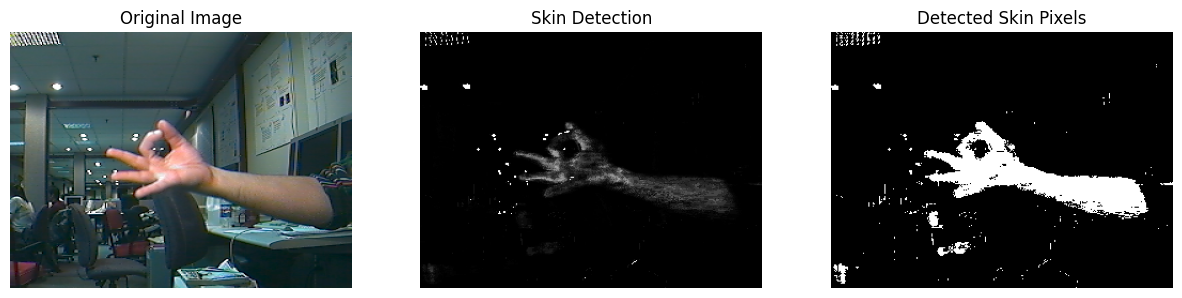

In [23]:
# Load positive skin histogram
positive_histogram = np.load('data/positive_histogram.npy')

# Read the image
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)

# Detect skin
result = detect_skin2(frame20, positive_histogram)

# Display images
display_images(frame20, result, result > 0.0001)

#### Using both positive and negative histograms

In [24]:
def detect_skin(image, positive_histogram, negative_histogram):
    """
    Detects skin in an image using positive and negative histograms.
    
    Parameters:
        image (numpy.ndarray): The input image array with shape (height, width, 3).
        positive_histogram (numpy.ndarray): The positive histogram.
        negative_histogram (numpy.ndarray): The negative histogram.
        
    Returns:
        numpy.ndarray: The output array with skin detection probabilities, shape (height, width).
    """
    
    vertical_size, horizontal_size, _ = image.shape
    histogram_bins = positive_histogram.shape[0]
    factor = 256 / histogram_bins
    
    result = np.zeros((vertical_size, horizontal_size))
    
    for vertical in range(vertical_size):
        for horizontal in range(horizontal_size):
            red = float(image[vertical, horizontal, 0])
            green = float(image[vertical, horizontal, 1])
            blue = float(image[vertical, horizontal, 2])
            
            red_index = int(np.floor(red / factor))
            green_index = int(np.floor(green / factor))
            blue_index = int(np.floor(blue / factor))
            
            skin_value = positive_histogram[red_index, green_index, blue_index]     # P(RGB | skin)
            non_skin_value = negative_histogram[red_index, green_index, blue_index] # P(RGB | non-skin)
            total = skin_value + non_skin_value
            
            if total != 0:
                # Bayes rule: P(skin | RGB) = P(RGB | skin) / (P(RGB | skin) + P(RGB | non-skin)) 
                # P(skin) = P(non-skin) = 0.5 are assumed to be equal and thus ignored.
                result[vertical, horizontal] = skin_value / total 
                
    return result


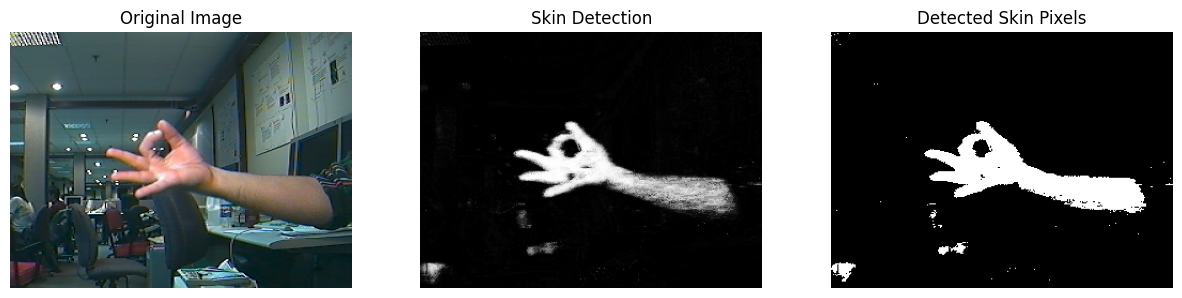

In [25]:
# Read histograms
negative_histogram = np.load('data/negative_histogram.npy')
positive_histogram = np.load('data/positive_histogram.npy')

# Read the image
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)

# Detect skin
result = detect_skin(frame20, positive_histogram, negative_histogram)

# Display images
display_images(frame20, result, result > 0.2)